In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, 
                             classification_report, roc_curve, auc)

# 1. Dataset Generation
np.random.seed(42)
n = 1000
df = pd.DataFrame({
    'Age': np.random.normal(40, 10, n).clip(18, 80),
    'Balance': np.random.normal(50000, 15000, n).clip(0),
    'IsActiveMember': np.random.choice([0, 1], n, p=[0.5, 0.5]),
    'NumProducts': np.random.choice([1, 2, 3], n)
})

# Balanced Target Logic (approx 40% Churn)
logit_link = 0.08*df['Age'] - 1.2*df['IsActiveMember'] - 2.0
prob = 1 / (1 + np.exp(-logit_link))
df['Exited'] = (prob > np.random.rand(n)).astype(int)
df.to_csv("Bank_data.csv")
print(f"Target Distribution:\n{df['Exited'].value_counts(normalize=True)}")

Target Distribution:
Exited
1    0.651
0    0.349
Name: proportion, dtype: float64


In [2]:
df.head()

,Age,Balance,IsActiveMember,NumProducts,Exited
0,44.967142,70990.331549,0,3,0
1,38.617357,63869.505244,0,3,1
2,46.476885,50894.455549,0,2,1
3,55.230299,40295.948334,0,2,1
4,37.658466,60473.349704,1,1,0


In [3]:
# 2. Fit Model
# The formula 'Exited ~ ...' defines the dependent and independent variables
model = smf.logit('Exited ~ Age + Balance + IsActiveMember + NumProducts', data=df).fit()

# Show Coefficients, P-values, and Log-Likelihood
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.559487
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 Exited   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      995
Method:                           MLE   Df Model:                            4
Date:                Sat, 04 Apr 2026   Pseudo R-squ.:                  0.1350
Time:                        03:52:40   Log-Likelihood:                -559.49
converged:                       True   LL-Null:                       -646.83
Covariance Type:            nonrobust   LLR p-value:                 1.036e-36
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.7797      0.450     -3.951      0.000      -2.662      -0.897
Age              

In [8]:
# 1. Obtenemos las probabilidades (P) que calcula la función Sigmoide
df['Probabilidad'] = model.predict(df)

# 2. Definimos el umbral (Threshold). Por defecto es 0.5
umbral = 0.5
df['Prediccion'] = (df['Probabilidad'] > umbral).astype(int)

# 3. Creamos una tabla con la Realidad vs Predicción (primeros 10 casos)
# Renombramos 'Exited' a 'Real' para que sea más claro
tabla_comparativa = df[['Exited', 'Prediccion', 'Probabilidad']]
tabla_comparativa.columns = ['Valor Real', 'Predicción', 'Probabilidad Calculada']

display(tabla_comparativa.head(30))

,Valor Real,Predicción,Probabilidad Calculada
0,0,1,0.845227
1,1,1,0.759717
2,1,1,0.872422
3,1,1,0.932560
4,0,1,0.523203
5,0,0,0.483588
6,1,1,0.938736
7,0,1,0.685253
8,0,0,0.404767
9,1,1,0.859770


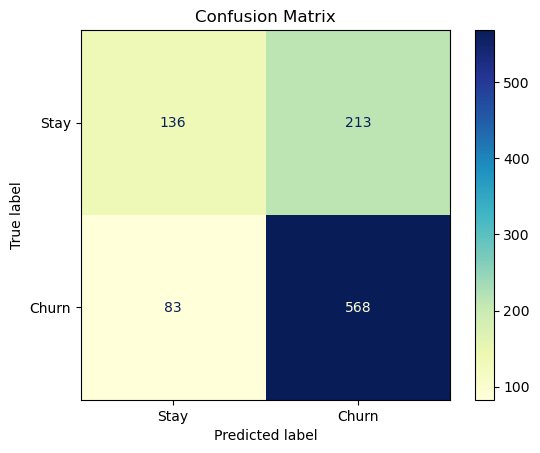


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.62      0.39      0.48       349
           1       0.73      0.87      0.79       651

    accuracy                           0.70      1000
   macro avg       0.67      0.63      0.64      1000
weighted avg       0.69      0.70      0.68      1000



In [11]:
# 4. Confusion Matrix (Slide 5/6)
cm = confusion_matrix(df['Exited'], df['Prediction'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Churn'])
disp.plot(cmap='YlGnBu')
plt.title("Confusion Matrix")
plt.show()

print("\n--- Classification Report ---")
print(classification_report(df['Exited'], df['Prediction']))

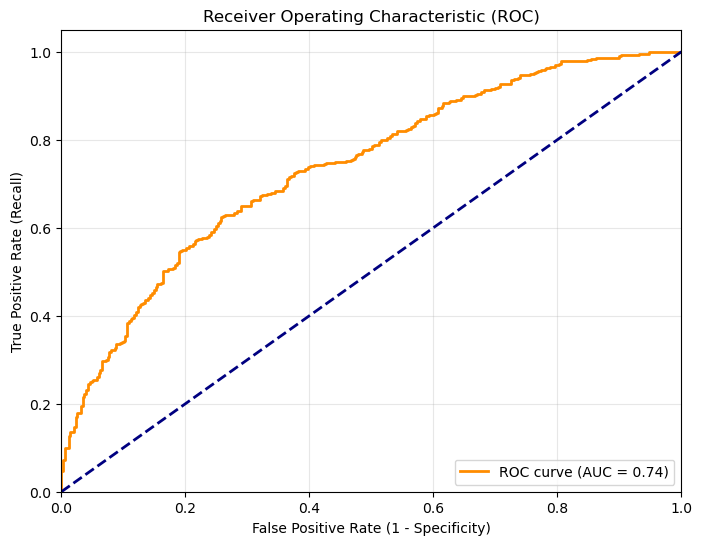

In [12]:
# 5. ROC Curve calculation
fpr, tpr, thresholds = roc_curve(df['Exited'], df['Prob_Churn'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()